# **$\textit{Лабораторная работа по ML №4  Жуховицкий А. Д. ( М8О-303Б-23 )}$**

Датасет:
- [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance)

Задачи:
- Выбрать датасет
- Загрузка и подготовка данных
- Провести базовый анализ: количество признаков, их типы (числовые/категориальные), наличие пропусков.
- Выбрать подмножество категориальных / дискретизируемых числовых признаков, отражающих принципиально важные для предсказания таргета знания (таргет также выбрать самостоятельно)
- Дискретизировать числовые признаки (если хотим использовать как входные данные, а также дискретизировать таргет, если он не является категорией)
- Определить целевую переменную
- Построение структуры Байесовской сети
- Определить логические зависимости между признаками (ориентированные рёбра).
- Составить структуру графа (DAG), отражающую причинно-следственные связи.
- Реализовать модель с помощью библиотеки PyAgrum или pgmpy:
- Визуализировать структуру сети.
- Обучение параметров сети
    - Обучить условные распределения (CPD) на данных с помощью метода максимального правдоподобия или байесовской оценки.
    - Проверить корректность полученных таблиц вероятностей (чтобы не было абсурдных значений)
- Инференс и анализ
    - Провести вероятностный вывод (inference): рассчитать вероятности целевой переменной при заданных наблюдениях.
    - Сравнить результаты при разных сценариях (взять например логически противоположные наблюдения.
- Выводы:
    - Сделать вывод о том, насколько Байесовская сеть адекватно описывает зависимости в данных.
    - Кратко сравнить Байесовскую сеть с классическими моделями (дерево решений, регрессия) по интерпретируемости и типу зависимостей.


# Базовый анализ

Загрузим датасет

In [97]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

student_performance = fetch_ucirepo(id=320)

X : pd.DataFrame = student_performance.data.features
y : pd.DataFrame = student_performance.data.targets

X

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,yes,yes,no,5,4,2,1,2,5,4
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,yes,yes,no,4,3,4,1,1,1,4
646,MS,F,18,U,GT3,T,1,1,other,other,...,yes,no,no,1,1,1,1,1,5,6
647,MS,M,17,U,LE3,T,3,1,services,services,...,yes,yes,no,2,4,5,3,4,2,6


Отключим лишние логи

In [98]:
import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

Выбираем как таргет финальную оценку студента, в датасете она называется G3, делаем единый датасет

In [99]:
df = X.join(y["G3"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 31 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

Пропусков нет. В датасете есть категориальные и уже дискретизированные числовые признаки, посмотрим насколько обширно количество вариантов этих категорий

In [100]:
for i in df.columns:
    print(df[i].nunique(), end=", ")

2, 2, 8, 2, 2, 2, 5, 5, 5, 5, 4, 3, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5, 24, 17, 

Вариантов категорий довольно мало, было бы очень удобно использовать label encoding, сделаем же это! Приведём категориальные признаки к числовым дискретизированным.

In [101]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3
0,0,0,18,1,0,0,4,4,0,4,...,0,0,4,3,4,1,1,3,4,11
1,0,0,17,1,0,1,1,1,0,2,...,1,0,5,3,3,1,1,3,2,11
2,0,0,15,1,1,1,1,1,0,2,...,1,0,4,3,2,2,3,3,6,12
3,0,0,15,1,0,1,4,2,1,3,...,1,1,3,2,2,1,1,5,0,14
4,0,0,16,1,0,1,3,3,2,2,...,0,0,4,3,2,1,2,5,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,1,0,19,0,0,1,2,3,3,2,...,1,0,5,4,2,1,2,5,4,10
645,1,0,18,1,1,1,3,1,4,3,...,1,0,4,3,4,1,1,1,4,16
646,1,0,18,1,0,1,1,1,2,2,...,0,0,1,1,1,1,1,5,6,9
647,1,1,17,1,1,1,3,1,3,3,...,1,0,2,4,5,3,4,2,6,10


Теперь можно посмотреть и корреляцию признаков между собой!

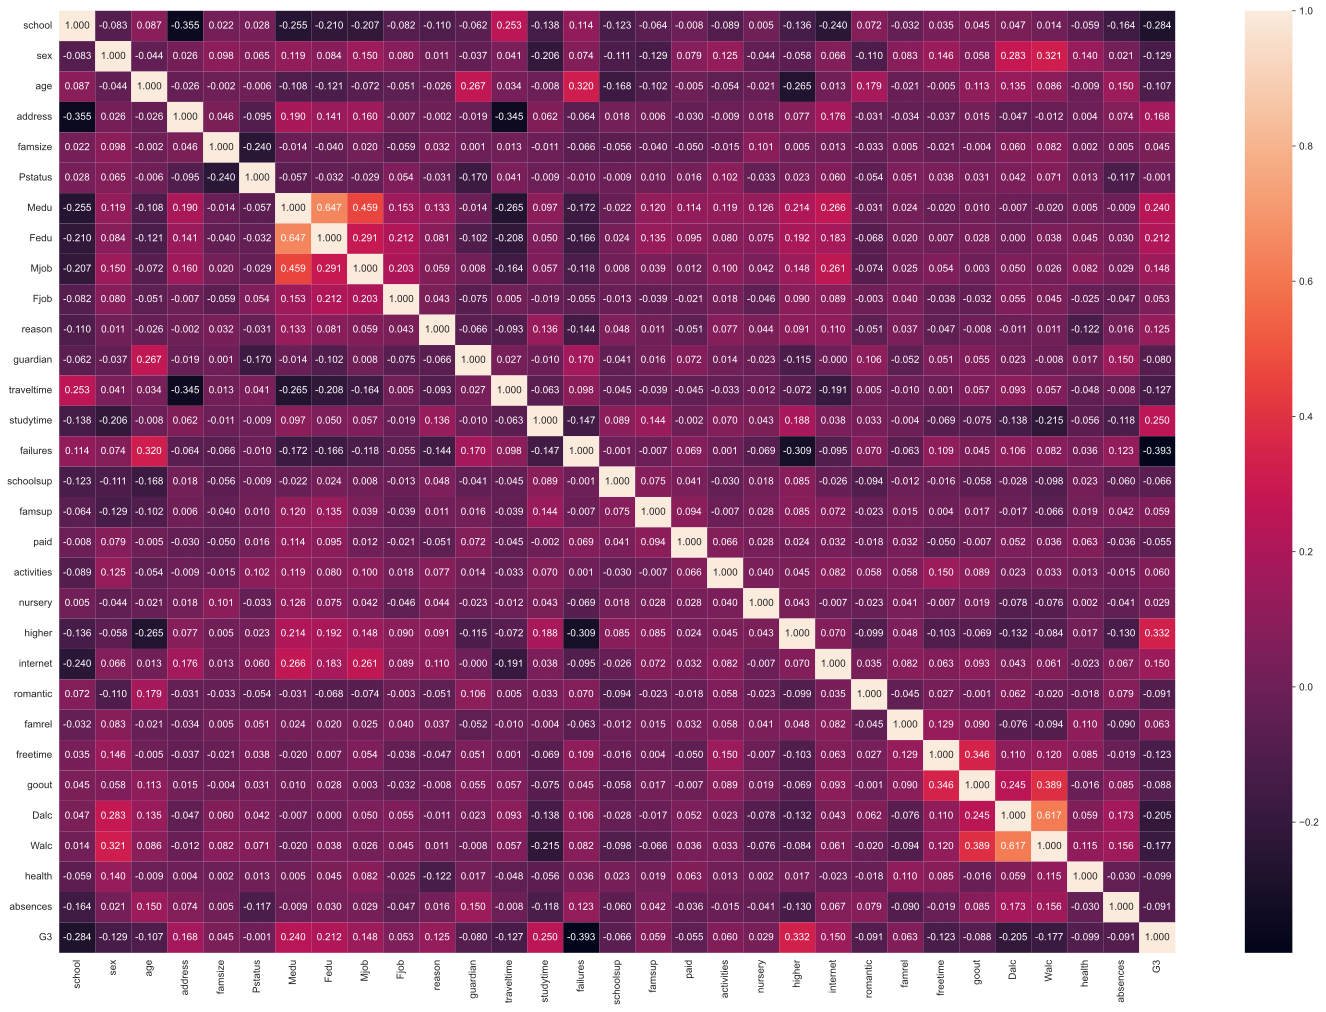

In [102]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = df.corr()

plt.figure(figsize=(25,17))
sns.heatmap(matrix, annot=True, fmt=".3f")
plt.show()

Сразу отбросим признаки с низкой корреляцией по порогу 0.2

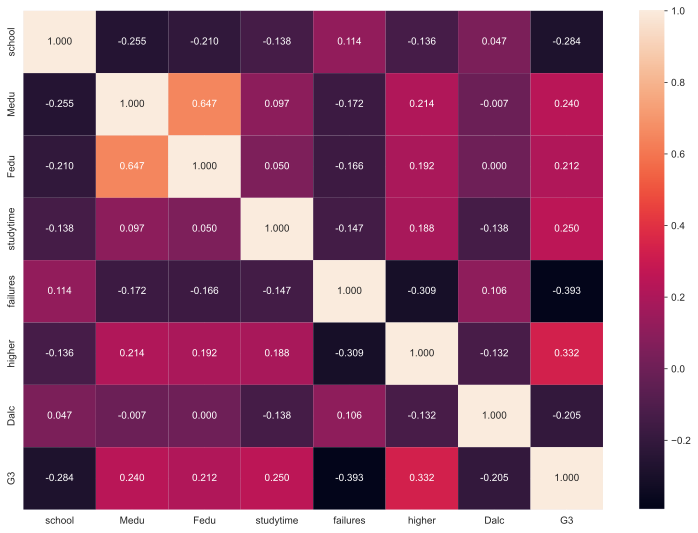

In [103]:
churn_corr = df.corr().abs()["G3"]
feature_names = df.columns.drop("G3")
cols_to_drop = churn_corr[feature_names][churn_corr[feature_names] < 0.2]

df.drop(cols_to_drop.index, inplace=True, axis=1)

plt.figure(figsize=(13, 9))
sns.heatmap(df.corr(), annot=True, fmt=".3f")
plt.show()

# Начало основной обработки и создание сети

Вот теперь можно разобрать значение каждого из столбцов, с которыми будем работать.

Столбцы:
- school - столбец, который определяет 1 из 2 учебных заведений, где мог быть студент
- Medu - уровень образования матери
- Fedu - уровень образования отца
- studytime - время, которое студент тратит на обучение
- failures - количество неудач, которые потерпел студент в прошлых классах
- higher - желает ли студент получить высшее образование
- Dalc - потребление алкоголя в рабочее время

Если подумать, то можно выстроить некоторые цепочки из признаков, которые действительно логически соотносятся.
Создадим сеть и добавим туда признаки.

In [104]:
from pyagrum import BayesNet, IntegerVariable, RangeVariable

network = BayesNet()
[network.add(IntegerVariable(name, name, df[name].unique().tolist())) for name in df.columns if name != "G3"]
network.add(RangeVariable("G3", "G3", 0, 19))

network

(pyagrum.BayesNet@0x1312f5e00) BN{nodes: 8, arcs: 0, domainSize: 160000, dim: 39, mem: 376o}

Основываясь на своём жизненном опыте, я составил кажущуюся мне логичной сеть из признаков. Например, от образования родителей зависит, в какое учебное заведение попадёт ребёнок и будет ли он стремиться к высшему образованию.

In [105]:
network.addArc("Fedu", "school")
network.addArc("Medu", "school")
network.addArc("Fedu", "higher")
network.addArc("Medu", "higher")
network.addArc("school", "failures")
network.addArc("higher", "G3")
network.addArc("failures", "G3")
network.addArc("Dalc", "G3")
network.addArc("studytime", "G3")

network

(pyagrum.BayesNet@0x1312f5e00) BN{nodes: 8, arcs: 9, domainSize: 160000, dim: 3111, mem: 25Ko 1016o}

Отлично, конфигурация сети готова! Обучим же её на наших данных и провалидируем результат, рассмотрим распределение вероятностей. Используем байесовскую оценку.

In [106]:
from pyagrum import BNLearner

learner = BNLearner(df, network)
# Используем сглаживание, чтобы не упереться в 0 в вероятности
learner.useSmoothingPrior()
bn = learner.learnParameters(network)

for item in bn.names():
    print(f"{item}: {bn.cpt(item)}")

Dalc: 
  Dalc                                           |
1        |2        |3        |4        |5        |
---------|---------|---------|---------|---------|
 0.6911  | 0.1865  | 0.0673  | 0.0275  | 0.0275  |

Fedu: 
  Fedu                                           |
0        |1        |2        |3        |4        |
---------|---------|---------|---------|---------|
 0.0122  | 0.2676  | 0.3211  | 0.2018  | 0.1972  |

higher: 
             ||  higher           |
Fedu  |Medu  ||0        |1        |
------|------||---------|---------|
0     |0     || 0.3333  | 0.6667  |
1     |0     || 0.5000  | 0.5000  |
2     |0     || 0.2000  | 0.8000  |
3     |0     || 0.5000  | 0.5000  |
4     |0     || 0.5000  | 0.5000  |
0     |1     || 0.1429  | 0.8571  |
[...13 more line(s) ...]
4     |3     || 0.0400  | 0.9600  |
0     |4     || 0.3333  | 0.6667  |
1     |4     || 0.1000  | 0.9000  |
2     |4     || 0.0345  | 0.9655  |
3     |4     || 0.0217  | 0.9783  |
4     |4     || 0.0309  | 0.9691  |

f

Подготовим инференс, чтобы пробовать рассмотреть какие-либо вероятности и проверять модель.

In [107]:
from pyagrum import LazyPropagation

ie = LazyPropagation(bn)
ie.makeInference()

print(ie.posterior("G3"))


  G3                                                                                                                                                                                                   |
0        |1        |2        |3        |4        |5        |6        |7        |8        |9        |10       |11       |12       |13       |14       |15       |16       |17       |18       |19       |
---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
 0.0292  | 0.0216  | 0.0215  | 0.0215  | 0.0215  | 0.0215  | 0.0231  | 0.0257  | 0.0430  | 0.0456  | 0.0934  | 0.1118  | 0.0945  | 0.1049  | 0.0841  | 0.0715  | 0.0572  | 0.0497  | 0.0354  | 0.0232  |



# Валидация результата и тесты

Посмотрим что получилось! Рассмотрим инференс для всей сети

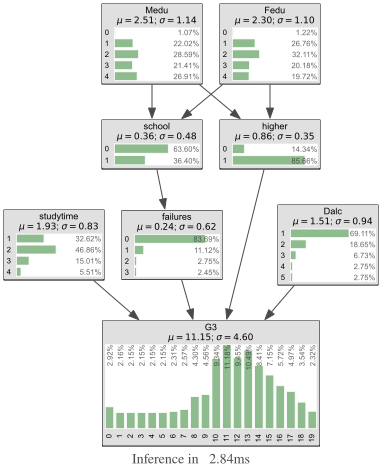

In [108]:
from pyagrum.lib.notebook import showInference

showInference(bn)

Попробуем поиспользовать нашу сеть и посмтреть вероятности для разных входных данных. Нарисуем сложную визуализацию ;(

Evidence: {'studytime': '4', 'failures': '0', 'Dalc': '1', 'higher': '1'}
Posterior P(G3):

  G3                                                                                                                                                                                                   |
0        |1        |2        |3        |4        |5        |6        |7        |8        |9        |10       |11       |12       |13       |14       |15       |16       |17       |18       |19       |
---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
 0.0222  | 0.0222  | 0.0222  | 0.0222  | 0.0222  | 0.0222  | 0.0222  | 0.0222  | 0.0222  | 0.0222  | 0.1111  | 0.0889  | 0.0889  | 0.1333  | 0.0667  | 0.0444  | 0.0444  | 0.0889  | 0.0667  | 0.0444  |



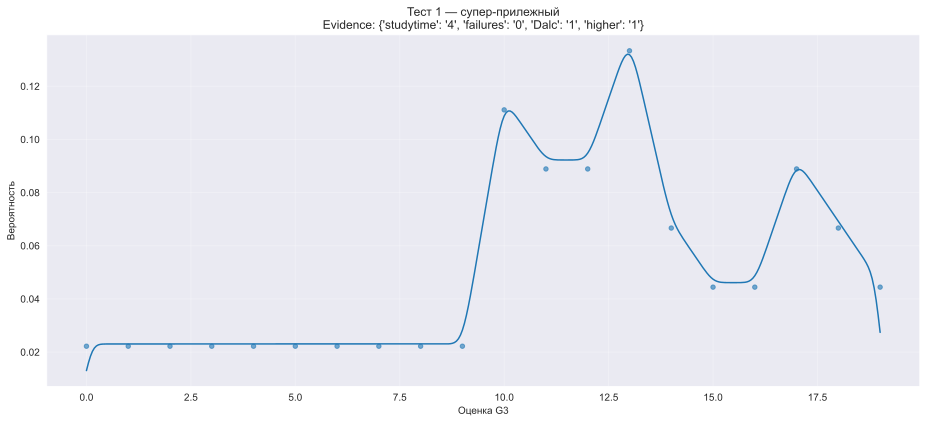

Evidence: {'studytime': '1', 'failures': '3', 'Dalc': '5', 'higher': '0'}
Posterior P(G3):

  G3                                                                                                                                                                                                   |
0        |1        |2        |3        |4        |5        |6        |7        |8        |9        |10       |11       |12       |13       |14       |15       |16       |17       |18       |19       |
---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0952  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  |



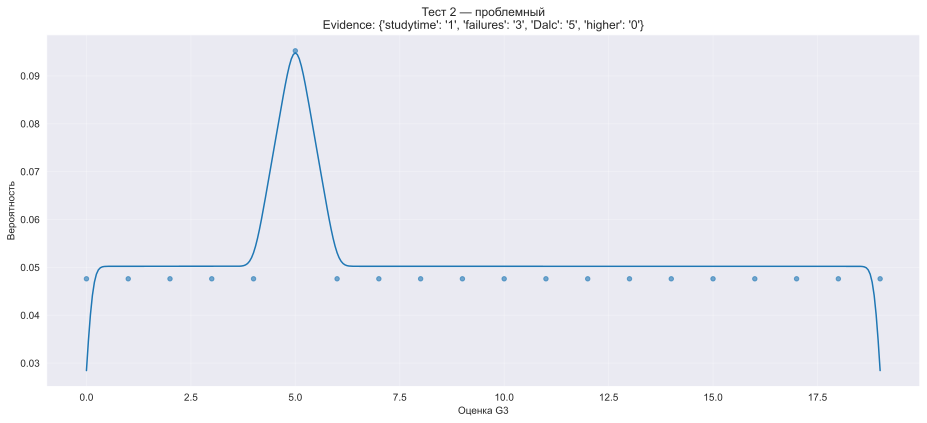

Evidence: {'studytime': '2', 'failures': '1', 'Dalc': '2', 'higher': '1'}
Posterior P(G3):

  G3                                                                                                                                                                                                   |
0        |1        |2        |3        |4        |5        |6        |7        |8        |9        |10       |11       |12       |13       |14       |15       |16       |17       |18       |19       |
---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0800  | 0.0400  | 0.1200  | 0.0800  | 0.0800  | 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0400  | 0.0400  |



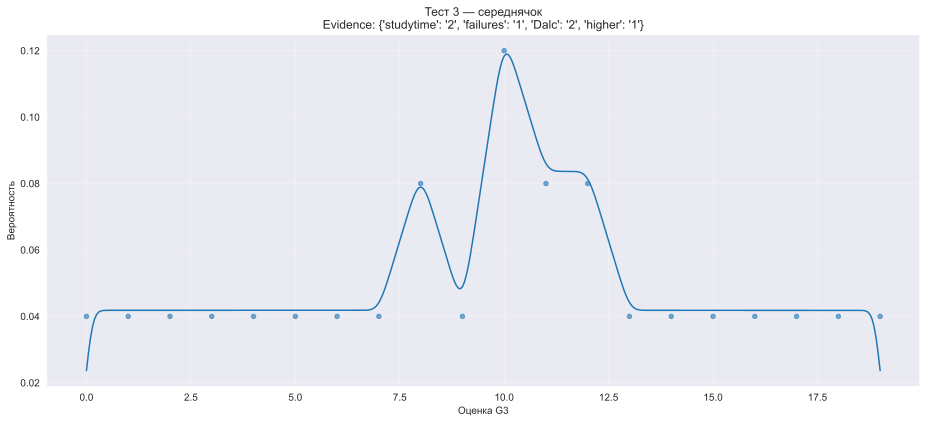

Evidence: {'studytime': '3', 'failures': '0', 'Dalc': '4', 'higher': '0'}
Posterior P(G3):

  G3                                                                                                                                                                                                   |
0        |1        |2        |3        |4        |5        |6        |7        |8        |9        |10       |11       |12       |13       |14       |15       |16       |17       |18       |19       |
---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0952  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  | 0.0476  |



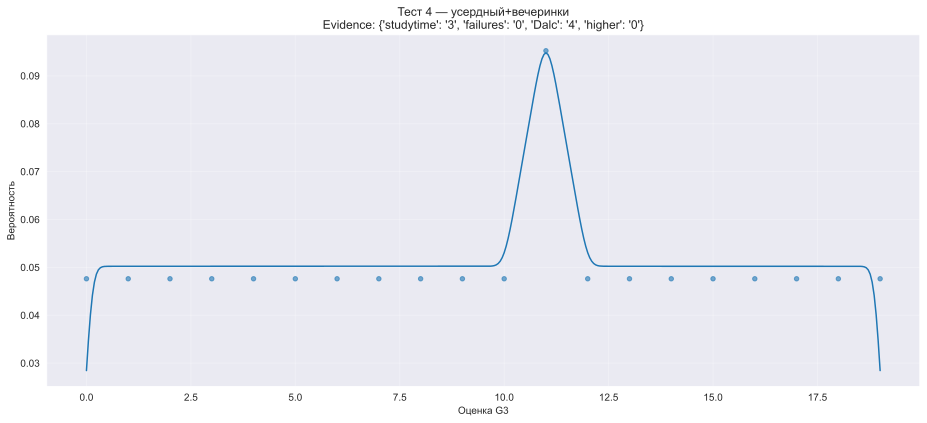

In [109]:
import numpy as np

tests = [
    {"name": "Тест 1 — супер-прилежный", "evidence": {"studytime":"4", "failures":"0", "Dalc":"1", "higher":"1"}},
    {"name": "Тест 2 — проблемный",      "evidence": {"studytime":"1", "failures":"3", "Dalc":"5", "higher":"0"}},
    {"name": "Тест 3 — середнячок",      "evidence": {"studytime":"2", "failures":"1", "Dalc":"2", "higher":"1"}},
    {"name": "Тест 4 — усердный+вечеринки","evidence": {"studytime":"3", "failures":"0", "Dalc":"4", "higher":"0"}},
]


def numeric_labels_for_var(bn, varname: str):
    """Получить числовые x-метки для переменной (если метки не числа — используем индексы)."""
    var = bn.variable(varname)
    labels = [str(l) for l in var.labels()]
    xs = []
    is_numeric = True
    for s in labels:
        try:
            xs.append(float(s))
        except ValueError:
            is_numeric = False
            break
    if not is_numeric:
        xs = list(range(len(labels)))
    return np.array(xs, dtype=float), labels


def gaussian_smooth(y, sigma_points=3.0, window=41):
    """Простое гауссово сглаживание без SciPy."""
    win = int(window)
    if win % 2 == 0:
        win += 1
    half = win // 2
    grid = np.arange(-half, half+1, dtype=float)
    kernel = np.exp(-0.5 * (grid / float(sigma_points))**2)
    kernel /= kernel.sum()
    return np.convolve(y, kernel, mode="same")


def posterior_curve_smooth(bn, varname: str, evidence: dict, n_points=400):
    """Считает posterior(varname|evidence), интерполирует и сглаживает кривую."""
    ie = LazyPropagation(bn)
    ev = {k: str(v) for k, v in evidence.items()}
    ie.setEvidence(ev)
    ie.makeInference()
    pot = ie.posterior(varname)
    print("Evidence:", ev)
    print("Posterior P(G3):")
    print(pot)

    x_discrete, _ = numeric_labels_for_var(bn, varname)
    y_discrete = np.array(pot.toarray()).reshape(-1).astype(float)
    s = y_discrete.sum()
    if s > 0:
        y_discrete = y_discrete / s

    if x_discrete.size == 1:
        x_smooth = np.linspace(x_discrete[0]-0.5, x_discrete[0]+0.5, n_points)
        y_linear = np.full_like(x_smooth, y_discrete[0], dtype=float)
    else:
        x_smooth = np.linspace(float(x_discrete.min()), float(x_discrete.max()), n_points)
        y_linear = np.interp(x_smooth, x_discrete, y_discrete)

    y_smooth = gaussian_smooth(y_linear, sigma_points=3.0, window=51)
    y_smooth = np.clip(y_smooth, 0, None)
    area = np.trapezoid(y_smooth, x_smooth)
    if area > 0:
        y_smooth = y_smooth / area

    return x_discrete, y_discrete, x_smooth, y_smooth


target = "G3"
for t in tests:
    xd, yd, xs, ys = posterior_curve_smooth(bn, target, t["evidence"])

    plt.figure(figsize=(13, 6))
    plt.plot(xs, ys)
    plt.scatter(xd, yd, s=20, alpha=0.6)

    plt.title(f'{t["name"]}\nEvidence: {t["evidence"]}')
    plt.xlabel("Оценка G3")
    plt.ylabel("Вероятность")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Видно, что модель более менее различает успеваемость студентов по их данным.

# Выводы:
    - Построенная байесовская сеть адекватно отражает причинно-статистические связи усилия $->$ успеваемость. Тесты показывают логичное поведение апостериоров, а сглаживание устранило проблему нулевых вероятностей.

    - Главное отличие заключается в том, что BN даёт обоснованную вероятностную картину и позволяет делать выводы при неполной информации, тогда как дерево и регрессия фокусируются на предсказании целевой переменной
    при полностью известных признаках. По интерпретируемости BN и дерево сопоставимы в маленьких задачах, но BN сохраняет смысл "причина -> следствие" и позволяет заглянуть под капот, а регрессия — нет.